In [20]:
import pandas as pd
import numpy as np
import requests
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from importlib_metadata import version


In [2]:
df = pd.read_csv("customer_data.csv")
print(df.head())

   CustomerID  Age  Gender  Income  Purchases  PurchaseFrequency  \
0        1001   56  Female   46976         37                 18   
1        1002   46  Female   69262         32                 15   
2        1003   32    Male   48776          9                  2   
3        1004   60    Male   55080         41                 10   
4        1005   25    Male   91842         35                  2   

   MembershipDuration  Churn  
0                  49      1  
1                  28      1  
2                  32      0  
3                  27      0  
4                  20      0  


In [3]:
import json
import pandas as pd
with open("customer_data.json")as file:
    data=json.load(file)
    df_json = pd.DataFrame(data)
    print(df_json)

    CustomerID  Age  Gender  Income  Purchases  PurchaseFrequency  \
0         1001   56  Female   46976         37                 18   
1         1002   46  Female   69262         32                 15   
2         1003   32    Male   48776          9                  2   
3         1004   60    Male   55080         41                 10   
4         1005   25    Male   91842         35                  2   
..         ...  ...     ...     ...        ...                ...   
95        1096   24    Male   41371         42                 13   
96        1097   26  Female  102371         31                  4   
97        1098   41  Female   27049          3                 16   
98        1099   18    Male   56616         40                 16   
99        1100   61  Female   45932         46                  2   

    MembershipDuration  Churn  
0                   49      1  
1                   28      1  
2                   32      0  
3                   27      0  
4          

In [4]:
import sqlite3

conn = sqlite3.connect(r"C:\Users\admin\Downloads\customer.db")

print("Connected Successfully")

conn.close()

Connected Successfully


In [5]:
import sqlite3

conn = sqlite3.connect("customer.db")

cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

print("Tables:", cursor.fetchall())

conn.close()

Tables: []


In [6]:
import sqlite3
import pandas as pd


conn = sqlite3.connect(r"C:\Users\admin\Downloads\customer.db")

query = "SELECT * FROM customers"

df = pd.read_sql(query, conn)

print(df.head())

conn.close()

   CustomerID  Age  Gender  Income  Purchases  PurchaseFrequency  \
0        1001   56  Female   46976         37                 18   
1        1002   46  Female   69262         32                 15   
2        1003   32    Male   48776          9                  2   
3        1004   60    Male   55080         41                 10   
4        1005   25    Male   91842         35                  2   

   MembershipDuration  Churn  
0                  49      1  
1                  28      1  
2                  32      0  
3                  27      0  
4                  20      0  


In [7]:

print("\nFetching API Data...")

url = "https://jsonplaceholder.typicode.com/users"

response = requests.get(url)

api_data = pd.DataFrame(response.json())

print(api_data.head())




Fetching API Data...
   id              name   username                      email  \
0   1     Leanne Graham       Bret          Sincere@april.biz   
1   2      Ervin Howell  Antonette          Shanna@melissa.tv   
2   3  Clementine Bauch   Samantha         Nathan@yesenia.net   
3   4  Patricia Lebsack   Karianne  Julianne.OConner@kory.org   
4   5  Chelsey Dietrich     Kamren   Lucio_Hettinger@annie.ca   

                                             address                  phone  \
0  {'street': 'Kulas Light', 'suite': 'Apt. 556',...  1-770-736-8031 x56442   
1  {'street': 'Victor Plains', 'suite': 'Suite 87...    010-692-6593 x09125   
2  {'street': 'Douglas Extension', 'suite': 'Suit...         1-463-123-4447   
3  {'street': 'Hoeger Mall', 'suite': 'Apt. 692',...      493-170-9623 x156   
4  {'street': 'Skiles Walks', 'suite': 'Suite 351...          (254)954-1289   

         website                                            company  
0  hildegard.org  {'name': 'Romaguera-Cron

In [8]:
print("\nDataset Info")
print(df.info())

print("\nSummary Statistics")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())



Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CustomerID          100 non-null    int64 
 1   Age                 100 non-null    int64 
 2   Gender              100 non-null    object
 3   Income              100 non-null    int64 
 4   Purchases           100 non-null    int64 
 5   PurchaseFrequency   100 non-null    int64 
 6   MembershipDuration  100 non-null    int64 
 7   Churn               100 non-null    int64 
dtypes: int64(7), object(1)
memory usage: 6.4+ KB
None

Summary Statistics
        CustomerID        Age         Income   Purchases  PurchaseFrequency  \
count   100.000000  100.00000     100.000000  100.000000         100.000000   
mean   1050.500000   40.88000   74535.090000   28.190000           9.800000   
std      29.011492   13.99082   29035.113065   13.355811           5.770003   
min    1001.

In [9]:

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
print("\nShape Before:", df.shape)

df.drop_duplicates(inplace=True)

print("Shape After:", df.shape)


Shape Before: (100, 8)
Shape After: (100, 8)


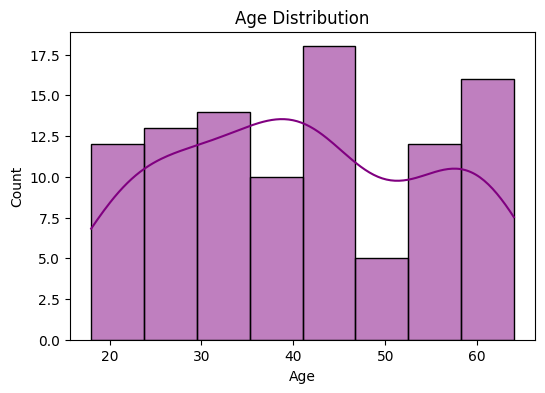

In [11]:

# Age 

plt.figure(figsize=(6,4))
sns.histplot(df["Age"], kde=True,color="purple")
plt.title("Age Distribution")
plt.show()

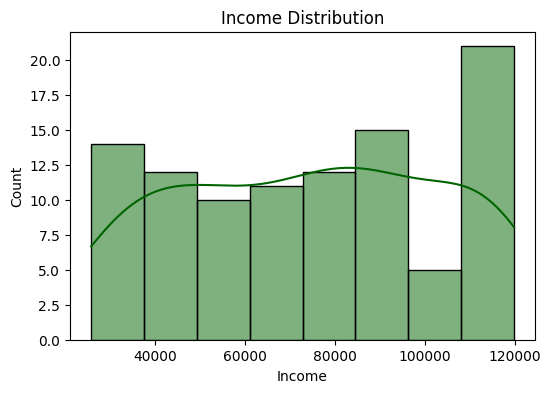

In [12]:

# Income 

plt.figure(figsize=(6,4))
sns.histplot(df["Income"], kde=True,color="darkgreen")
plt.title("Income Distribution")
plt.show()


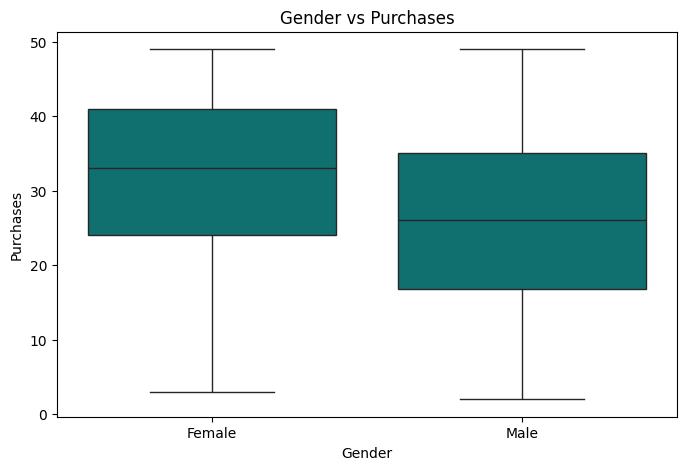

In [13]:

# Gender vs Purchase

plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Gender',
    y='Purchases',   
    data=df,color="teal"
)

plt.title('Gender vs Purchases')
plt.xlabel('Gender')
plt.ylabel('Purchases')

plt.show()

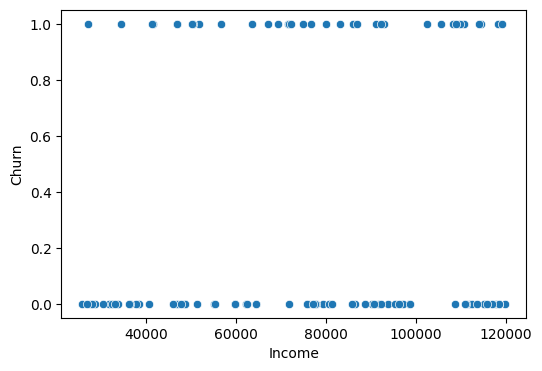

In [14]:

# Income vs churn


plt.figure(figsize=(6,4))
sns.scatterplot(
    x="Income",
    y="Churn",
    data=df
)

plt.show()

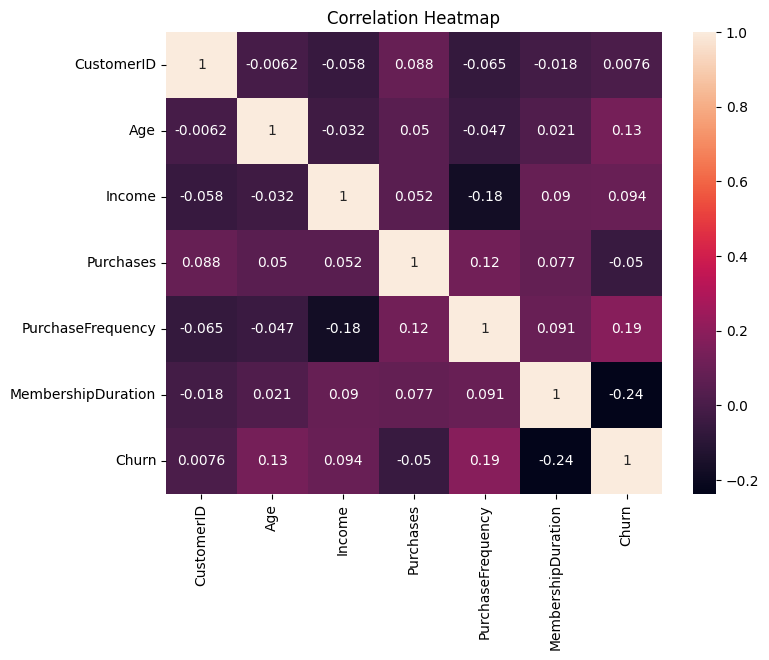

In [15]:

# CORRELATION HEATMAP

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()


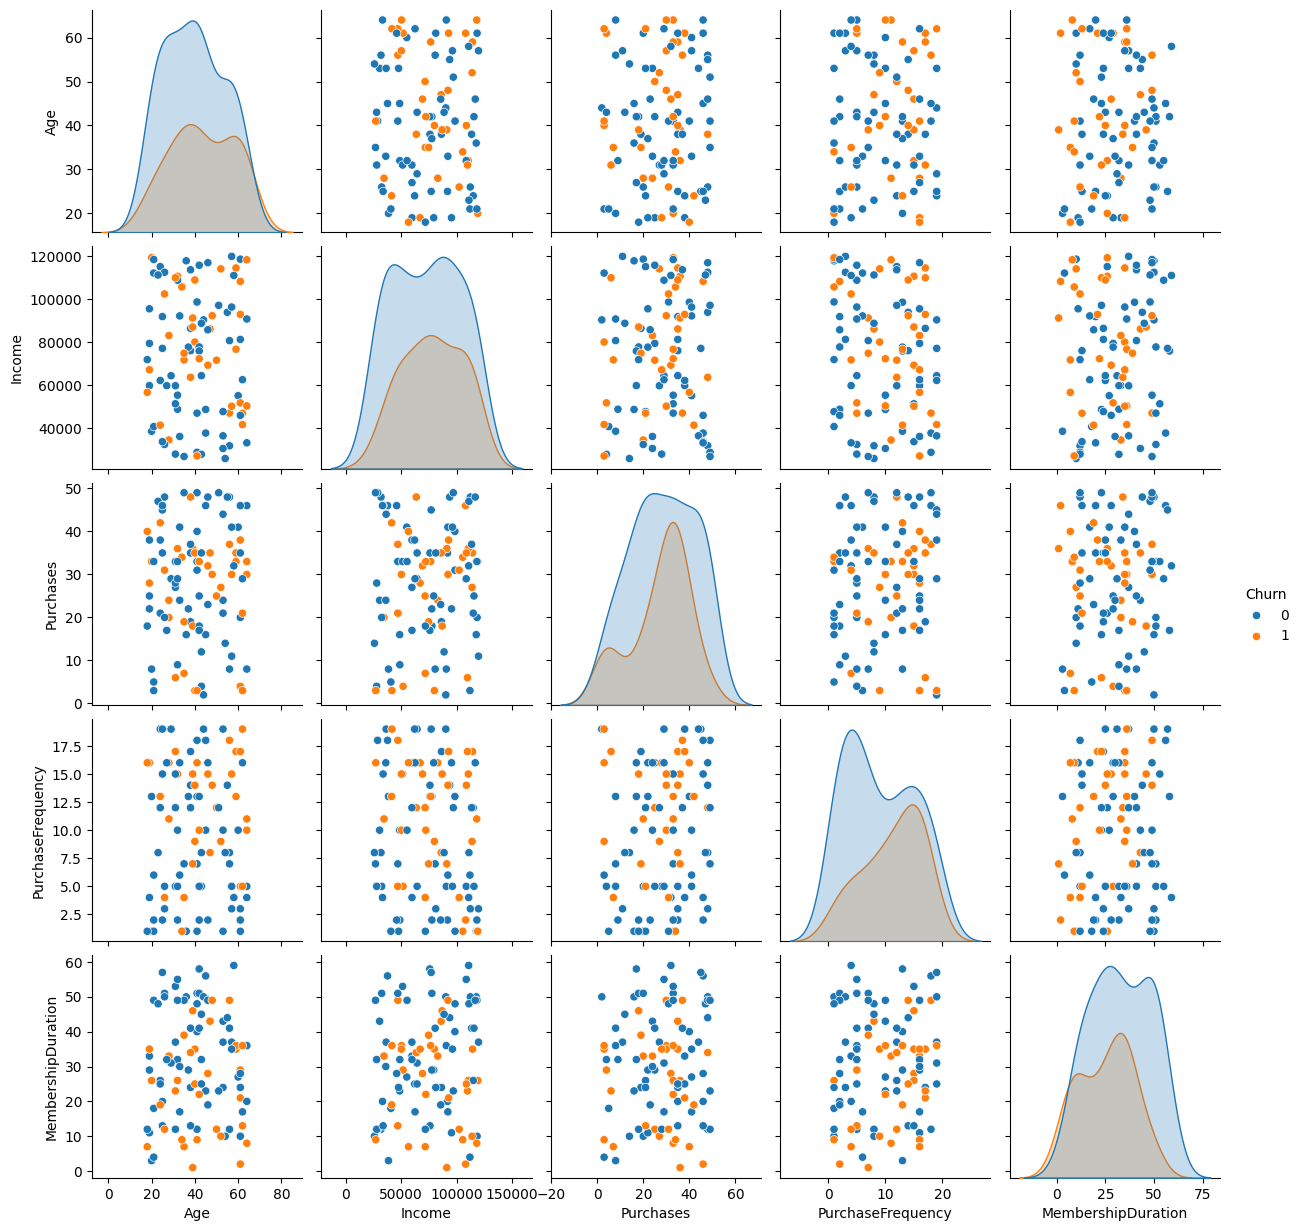

In [16]:
sns.pairplot(
    df[["Age", "Income", "Gender", "Churn","Purchases","PurchaseFrequency","MembershipDuration"]],
    hue="Churn"
)

plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv("customer_data.csv")

print(df.head())




   CustomerID  Age  Gender  Income  Purchases  PurchaseFrequency  \
0        1001   56  Female   46976         37                 18   
1        1002   46  Female   69262         32                 15   
2        1003   32    Male   48776          9                  2   
3        1004   60    Male   55080         41                 10   
4        1005   25    Male   91842         35                  2   

   MembershipDuration  Churn  
0                  49      1  
1                  28      1  
2                  32      0  
3                  27      0  
4                  20      0  


In [26]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title="Customer Dataset Report",
    explorative=True
)

profile.to_file("customer_report.html")

print("Report Generated Successfully!")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<?, ?it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Report Generated Successfully!
